In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import os

file_path = os.path.expanduser("~/Desktop/regge.xlsx")
df = pd.read_excel(file_path)

model_avail = df[["Preis", "Verfugbar", "verkauft"]].copy()


def clean_price(x):
    if pd.isna(x):
        return np.nan
    x = (
        str(x)
        .replace("EUR", "")
        .replace("€", "")
        .replace(".", "")
        .replace(",", ".")
        .strip()
    )
    try:
        return float(x)
    except:
        return np.nan


def clean_number(x):
    if pd.isna(x) or x == "N/A":
        return np.nan
    x = str(x).replace("+", "").replace(".", "").replace(",", ".").strip()
    try:
        return float(x)
    except:
        return np.nan


model_avail["price"] = model_avail["Preis"].apply(clean_price)
model_avail["available_stock"] = model_avail["Verfugbar"].apply(clean_number)
model_avail["number_sold"] = model_avail["verkauft"].apply(clean_number)

model_avail = model_avail.drop(columns=["Preis", "Verfugbar", "verkauft"])
model_avail = model_avail.dropna()

model_avail["sold_available_ratio"] = (
    model_avail["number_sold"] / model_avail["available_stock"]
)

model_avail = model_avail.replace([np.inf, -np.inf], np.nan).dropna()

X = model_avail[["available_stock", "number_sold", "sold_available_ratio"]]
y = model_avail["price"]

X = X.astype(float)
y = y.astype(float)

X = sm.add_constant(X)

availability_model = sm.OLS(y, X).fit()

availability_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.167
Model:                            OLS   Adj. R-squared:                  0.106
Method:                 Least Squares   F-statistic:                     2.743
Date:                Fri, 08 May 2026   Prob (F-statistic):             0.0554
Time:                        13:22:40   Log-Likelihood:                -251.35
No. Observations:                  45   AIC:                             510.7
Df Residuals:                      41   BIC:                             517.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  820.8979     24.161     33.976      0.000     772.104     869.692
available_stock          2.7590      2.942      0.938      0.354      -3.183       8.701
number_sold             -0.0349      0.045     -0.775      0.443      -0.126       0.056
sold_available_ratio     0.0085      0.415      0.020      0.984      -0.831       0.848
==============================================================================
Omnibus:                        0.931   Durbin-Watson:                   1.851
Prob(Omnibus):                  0.628   Jarque-Bera (JB):                0.381
Skew:                          -0.200   Prob(JB):                        0.827
Kurtosis:                       3.208   Cond. No.                     2.36e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.36e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

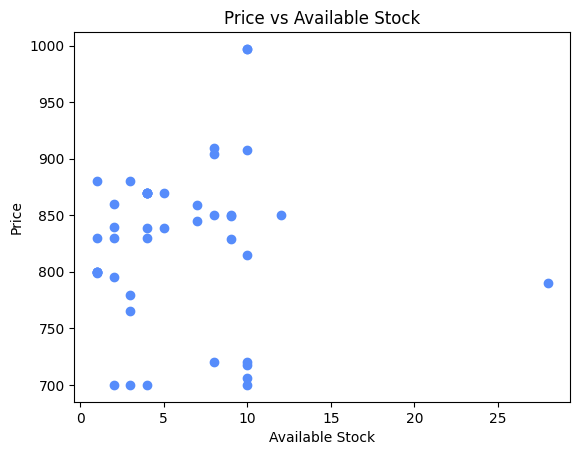

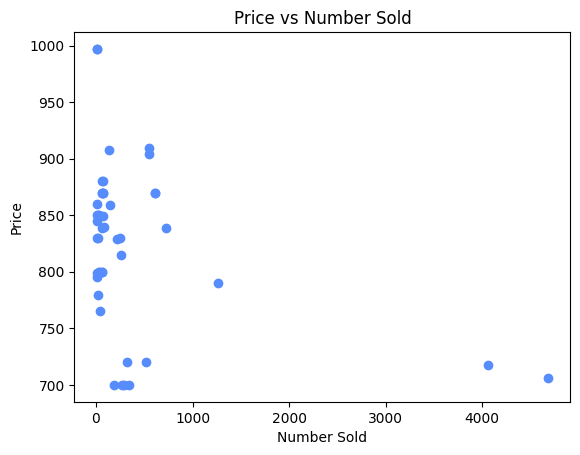

In [2]:
import matplotlib.pyplot as plt

plt.scatter(model_avail["available_stock"], model_avail["price"])
plt.xlabel("Available Stock")
plt.ylabel("Price")
plt.title("Price vs Available Stock")
plt.show()

plt.scatter(model_avail["number_sold"], model_avail["price"])
plt.xlabel("Number Sold")
plt.ylabel("Price")
plt.title("Price vs Number Sold")
plt.show()